Basic settings

In [1]:
from utgc.runner import EnsembleRunner
runner = EnsembleRunner.from_config('output/SA/testrun/config.yaml')

Initializing runner from configuration: output/SA/testrun/config.yaml
Loaded 2745 segments from data/UT_vtds.geojson
Loaded 4 districts from maps/US-House/2025_USH_Leg-C/2025_USH_Leg-C.shp
Projecting to EPSG:26912
Found 1978 nodes assigned to 254 incorporated municipalities
Assigning unique IDs to unincorporated nodes...
Assigned unique IDs to 767 unincorporated nodes
Total unique MUNIIDs: 1021
  Graph built with 2745 nodes, 7641 edges
Population deviation tolerance: 0.100000%
Constraint: split max 4 muni
Constraint: max 0 multi-splits of muni
  Added locality split updater: 'ls_muni'
    Ignoring updater in output: 'ls_muni'
  Added split updater: 'split_muni'
  Added multi-split updater: 'muni_multi_splits'
Constraint: split max 5 county
Constraint: max 0 multi-splits of county
  Added locality split updater: 'ls_county'
    Ignoring updater in output: 'ls_county'
  Added split updater: 'split_county'
  Added multi-split updater: 'county_multi_splits'
Constraint: prevent same map fro

Election settings

In [2]:
runner = (runner
    .add_election_updaters(
        years=[2016, 2020, 2024],
        elections=['PRE','GOV','ATG','AUD','TRE'],
        parties_to_columns_override={
            "2024GOV":{"R1":"G24GOVRHEN","R2":"G24GOVNCLA"}
        }
    )
    .add_election_aggregator(
        "sb1011_data",
        ["2016PRE", "2016GOV", "2016ATG", "2016AUD", "2016TRE", "2020PRE", "2020GOV", "2020ATG", "2024PRE", "2024GOV", "2024ATG", "2024AUD", "2024TRE"],
        parties=["D", "R", "-"]
    )
    .add_election_metric_updaters(
        "sb1011_data",
        ["partisan_bias_utah", "partisan_bias", "mean_median", "efficiency_gap", "stdev_partisan_share", "majority_partisan_shares", "majority_seats"]
    )
)

  Added election updater: '2016ATG'
    Parties to columns: {'D': 'G16ATGDHAR', 'R': 'G16ATGRREY', '-': 'G16ATG-TOT'}
    Ignoring updater in output: '2016ATG'
  Added election updater: '2016AUD'
    Parties to columns: {'R': 'G16AUDRDOU', 'D': 'G16AUDDMIT', '-': 'G16AUD-TOT'}
    Ignoring updater in output: '2016AUD'
  Added election updater: '2016GOV'
    Parties to columns: {'D': 'G16GOVDWEI', 'R': 'G16GOVRHER', '-': 'G16GOV-TOT'}
    Ignoring updater in output: '2016GOV'
  Added election updater: '2016PRE'
    Parties to columns: {'D': 'G16PREDCLI', 'R': 'G16PRERTRU', '-': 'G16PRE-TOT'}
    Ignoring updater in output: '2016PRE'
  Added election updater: '2016TRE'
    Parties to columns: {'D': 'G16TREDHAN', 'R': 'G16TRERDAM', '-': 'G16TRE-TOT'}
    Ignoring updater in output: '2016TRE'
  Added election updater: '2020ATG'
    Parties to columns: {'R': 'G20ATGRREY', 'D': 'G20ATGDSKO', '-': 'G20ATG-TOT'}
    Ignoring updater in output: '2020ATG'
  Added election updater: '2020GOV'
    

In [3]:
# Set up visualization of sample maps
import os
import utgc.plotting as gcplot
import utgc.notebookhelper as nbh

munis, counties = nbh.load_boundaries_from_shapefiles()

runner = runner.add_runtime_callback(
    name="render_maps",
    frequency=10,
    action=lambda partition, step, output_dir: gcplot.visualize_partition(
        partition,
        step,
        os.path.join(output_dir, "maps"),
        counties=counties,
        municipalities=munis,
        split_munis_count=partition["split_muni"],
        split_counties_count=partition["split_county"],
    )
)

Loaded 29 counties from data/bounds/UtahCountyBoundaries/ut_cnty_2020_bound.shp
Loaded 259 municipalities from data/bounds/UtahMunicipalBoundaries/Municipalities.shp
Registered callback 'render_maps' (<lambda>) to run every 10 steps.


In [4]:
runner = runner.precondition(steps=100)
runner.run(
    name="ensemble",
    output_dir="output/SA/",
    num_steps=500,
)

=== Preconditioning ===
Starting preconditioning...


100%|██████████| 100/100 [01:02<00:00,  1.59it/s]

  Preconditioning successful! All tolerances met.
=== MCMC ensemble ===


  0%|          | 0/500 [00:00<?, ?it/s]

Configured neutral run with 500 steps
Running Markov chain...


In [5]:
import json

comparison_maps = {
    "Map C": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Leg-C/2025_USH_Leg-C.shp"
    ),
    "Plaintiff 1": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Plaintiff-1/2025_USH_Plaintiff-1.shp"
    ),
    "Plaintiff 2": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Plaintiff-2/2025_USH_Plaintiff-2.shp"
    ),
    "2021 Enacted": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_Enacted/2021_USH_Enacted.shp"
    ),
    "UIRC Orange": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Orange/2021_USH_UIRC-Orange.shp"
    ),
    "UIRC Purple": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Purple/2021_USH_UIRC-Purple.shp"
    ),
    "UIRC Public": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Public/2021_USH_UIRC-Public.shp"
    ),
}

with open("output/SA/ensemble/comparison_maps.json", "w") as f:
    json.dump(comparison_maps, f, indent=2)

In [6]:
import json
from utgc.results import ResultSet

if "comparison_maps" not in locals():
    with open("output/SA/ensemble/comparison_maps.json", "r") as f:
        comparison_maps = json.load(f)

results = ResultSet(output_file="output/SA/ensemble/output.jsonl")

✓ ResultSet created.
  - Contains results for 500 plans.
  - Output directory: output/SA/ensemble


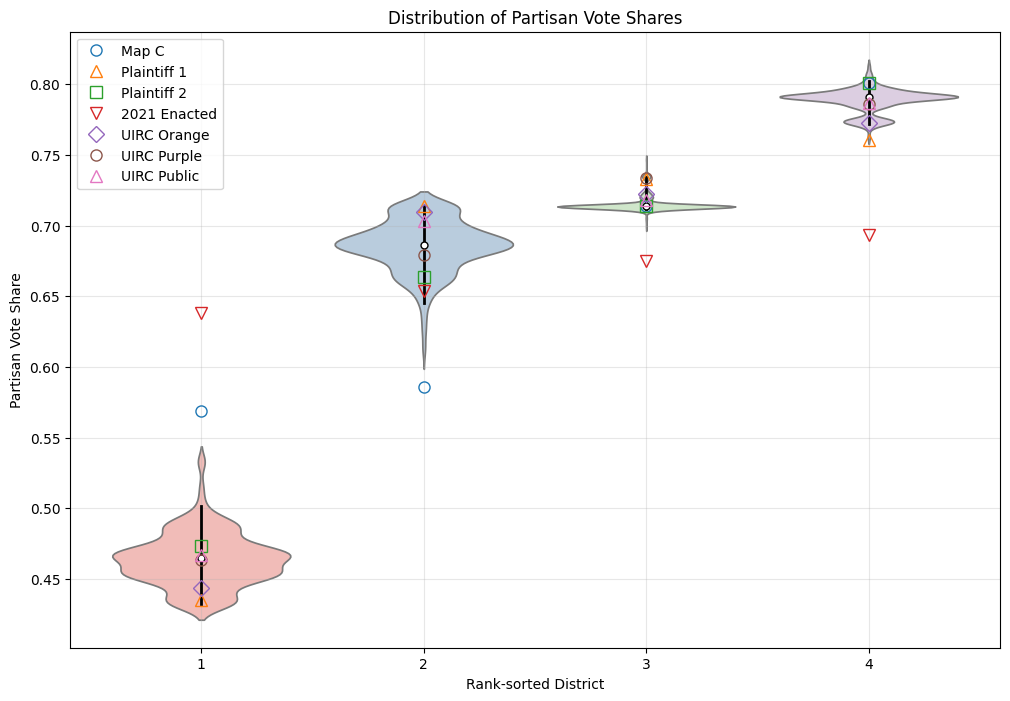

In [7]:
from math import ceil
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def district_plot(
        results,
        metric_name,
        reference_values={},
        highlight_interval=[0.025, 0.975],
        relative_to_median=False
    ):
    district_data = []
    for _, row in results.df.iterrows():
        sorted_values = sorted(row[metric_name].values())
        district_data.append(sorted_values)

    max_districts = max(len(step_data) for step_data in district_data) if district_data else 0
    sorted_df = pd.DataFrame(district_data, columns=[f'{i+1}' for i in range(max_districts)])

    # if relative_to_median, compute the difference between each value and the median
    medians = sorted_df.median()
    if relative_to_median:
        sorted_df = sorted_df.sub(medians, axis=1)
        plt_medians = medians.sub(medians, axis=0)
    else:
        plt_medians = medians

    plt.figure(figsize=(12, 8))
    sns.violinplot(sorted_df, orient='v', inner=None, palette="Pastel1")

    percentiles = sorted_df.quantile(highlight_interval)

    for i, col in enumerate(sorted_df.columns):
        y_low = percentiles.loc[highlight_interval[0], col]
        y_high = percentiles.loc[highlight_interval[1], col]
        y_median = plt_medians[col]
        plt.plot([i, i], [y_low, y_high], color='black', lw=2)
        plt.plot(i, y_median, marker='o', mfc='white', mec='k', markersize=5)
    
    if reference_values:
        markers = ['o', '^', 's', 'v', 'D'] * ceil(len(reference_values) / 6)
        colors = plt.cm.tab10.colors
        for i, (label, ref_dict) in enumerate(reference_values.items()):
            sorted_reference_values = sorted(ref_dict.values())
            for rank_idx, value in enumerate(sorted_reference_values):
                if relative_to_median:
                    value = value - medians.iloc[rank_idx]

                plt.plot(rank_idx, value, markers[i], mec=colors[i], mfc="None", markersize=8, label=label if rank_idx == 0 else "")

    plt.xlabel('Rank-sorted District')
    if relative_to_median:
        plt.ylabel('Relative Vote Share')
    else:
        plt.ylabel('Partisan Vote Share')
    plt.title('Distribution of Partisan Vote Shares')
    if reference_values:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

district_plot(
    results,
    "majority_partisan_shares",
    reference_values={k: v["majority_partisan_shares"] for k, v in comparison_maps.items()},
    relative_to_median=False
)